In [1]:
import numpy as np
import matplotlib.pyplot as plt

file_paths = [
    'initial_input.npy',
    'groundtruth_210.npy',
    'Triton_210_day.npy',
    'Fuxi_210.npy',
    'Pangu_210.npy',
    'SFNO_210.npy',]

data = {file: np.load(file) for file in file_paths}

for file, array in data.items():
    print(f"File: {file}, Shape: {array.shape}")

File: initial_input.npy, Shape: (69, 180, 360)
File: groundtruth_210.npy, Shape: (69, 180, 360)
File: Triton_210_day.npy, Shape: (69, 180, 360)
File: Fuxi_210.npy, Shape: (69, 180, 360)
File: Pangu_210.npy, Shape: (69, 180, 360)
File: SFNO_210.npy, Shape: (69, 180, 360)


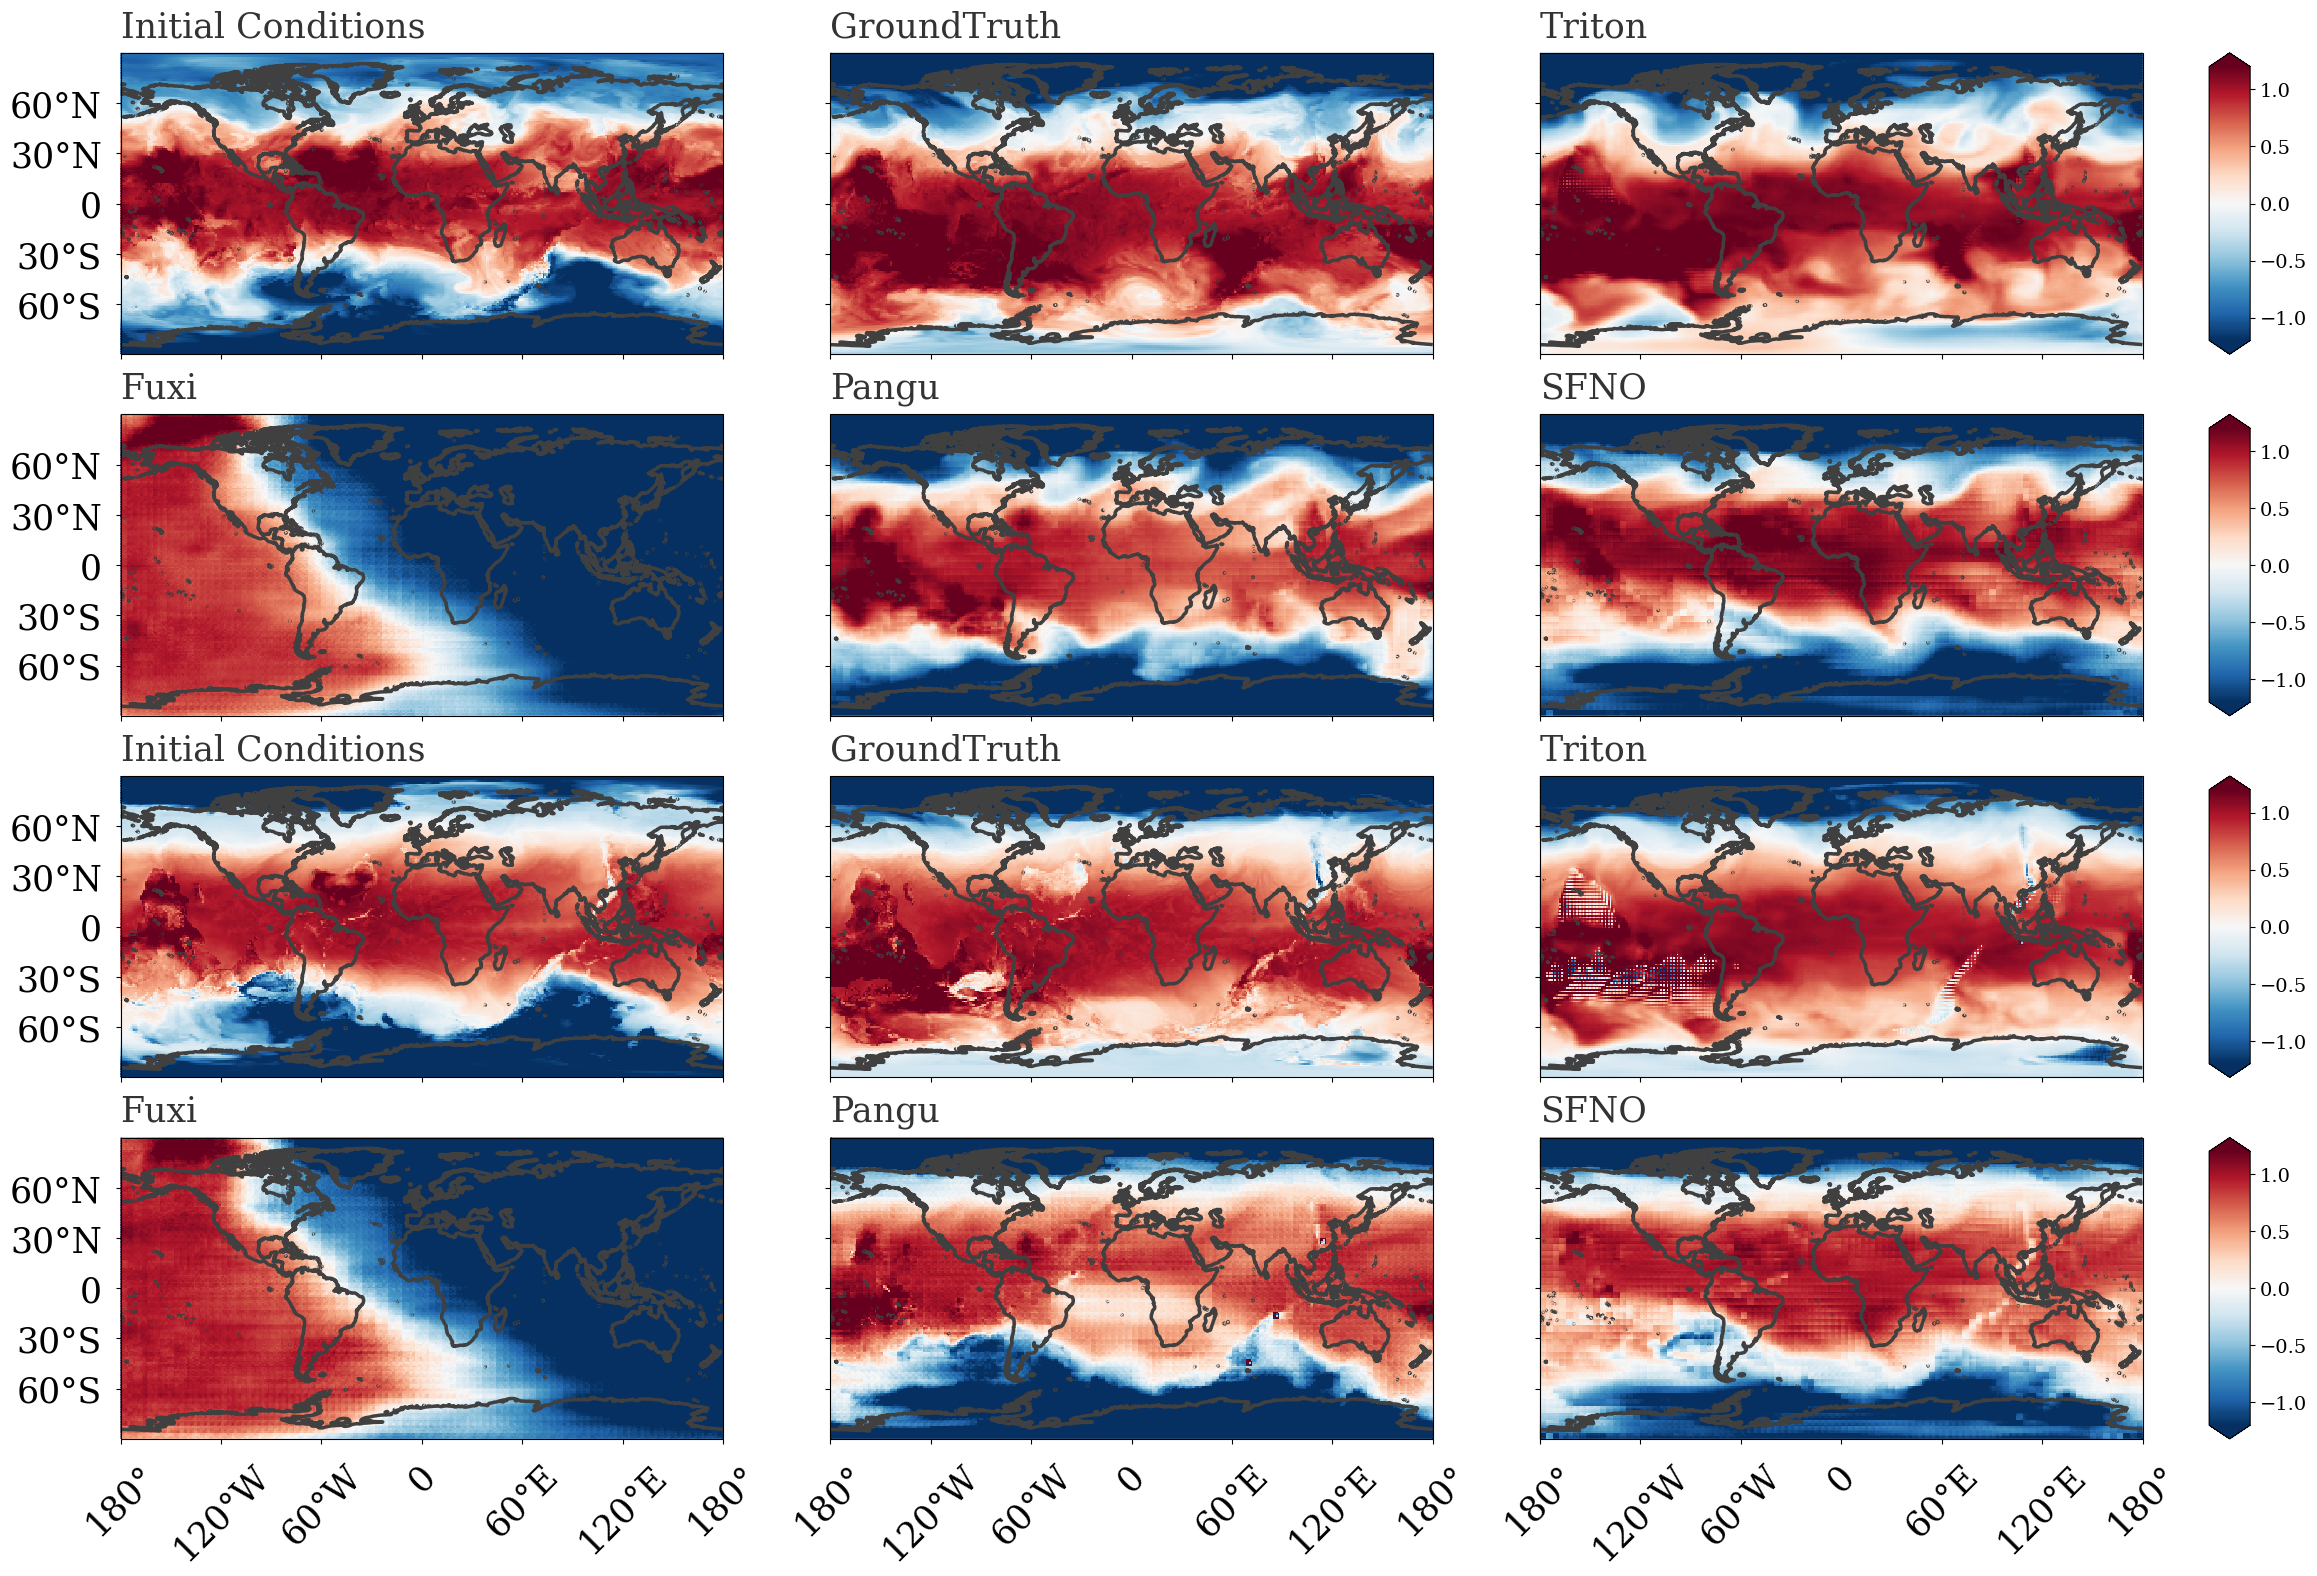

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 35,  
    "axes.titlesize": 35, 
    "axes.labelsize": 35,  
    "xtick.labelsize": 40,  
    "ytick.labelsize": 40, 
    "mathtext.fontset": "stix"
})


file_paths = [
    'initial_input.npy',
    'groundtruth_210.npy',
    'Triton_210_day.npy',
    'Fuxi_210.npy',
    'Pangu_210.npy',
    'SFNO_210.npy',
]

data = {file: np.load(file) for file in file_paths}

model_mapping = {
    'Initial Conditions': 'initial_input.npy',
    'GroundTruth': 'groundtruth_210.npy',
    'Triton': 'Triton_210_day.npy',
    'Fuxi': 'Fuxi_210.npy',
    'Pangu': 'Pangu_210.npy',
    'SFNO': 'SFNO_210.npy'
}

variables = [
    {   # T850
        'index': 4 + 2*13 + 10,
        'cmap': 'RdBu_r',
        'unit': 'K'
    },
    
    {   # T10M
        'index': 2,  
        'cmap': 'RdBu_r',
        'unit': 'm'
    }

]

lon = np.linspace(-180, 180, 360)
lat = np.linspace(-90, 90, 180)
COASTLINE_STYLE = dict(linewidth=2.5, edgecolor='#404040')
model_order = ['Initial Conditions', 'GroundTruth', 'Triton', 'Fuxi', 'Pangu', 'SFNO']

fig = plt.figure(figsize=(28, 18))
gs = GridSpec(nrows=4, ncols=4, 
             width_ratios=[1, 1, 1, 0.06],
             height_ratios=[1, 1, 1, 1],
             hspace=0.2, wspace=0.05)

for var_idx, var in enumerate(variables):
    var_data = {}
    for model in model_order:
        key = model_mapping[model]
        var_data[model] = data[key][var['index']]
    
    data_pool = np.concatenate([d.flatten() for d in var_data.values()])
    abs_max = np.max(np.abs(data_pool)) if var_idx == 0 else np.nan 
    vmin, vmax = (-abs_max, abs_max) if var_idx == 0 else np.percentile(data_pool, [2, 98])
    
    for row in range(2):
        row_offset = var_idx * 2
        
        for col in range(3):
            model_index = row * 3 + col
            if model_index >= len(model_order): break
            
            model = model_order[model_index]
            ax = fig.add_subplot(gs[row_offset + row, col], 
                                projection=ccrs.PlateCarree())
            
            mesh = ax.pcolormesh(lon, lat, var_data[model],
                               cmap=var['cmap'],
                               vmin=-1.2, vmax=1.2,
                               transform=ccrs.PlateCarree())
            
            ax.add_feature(cfeature.COASTLINE.with_scale('50m'), **COASTLINE_STYLE)
            
            ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
            ax.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
            
            ax.set_title(model, fontsize=25, pad=12, loc='left', color='#333333')
            
            if row_offset + row == 3:  
                ax.xaxis.set_major_formatter(plt.FixedFormatter(['180°','120°W','60°W','0','60°E','120°E','180°']))
                ax.tick_params(axis='x', labelsize=25, rotation=45, pad=10)
            else:
                ax.set_xticklabels([])
                
            if col == 0:  
                ax.yaxis.set_major_formatter(plt.FixedFormatter(['60°S','30°S','0','30°N','60°N']))
                ax.tick_params(axis='y', labelsize=25, pad=10)
            else:
                ax.set_yticklabels([])
                
        cax = fig.add_subplot(gs[row_offset + row, 3])
        cbar = plt.colorbar(mesh, cax=cax, orientation='vertical',
                          extend='both', shrink=0.8)
        cbar.ax.tick_params(labelsize=14)

plt.savefig('clean_model_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


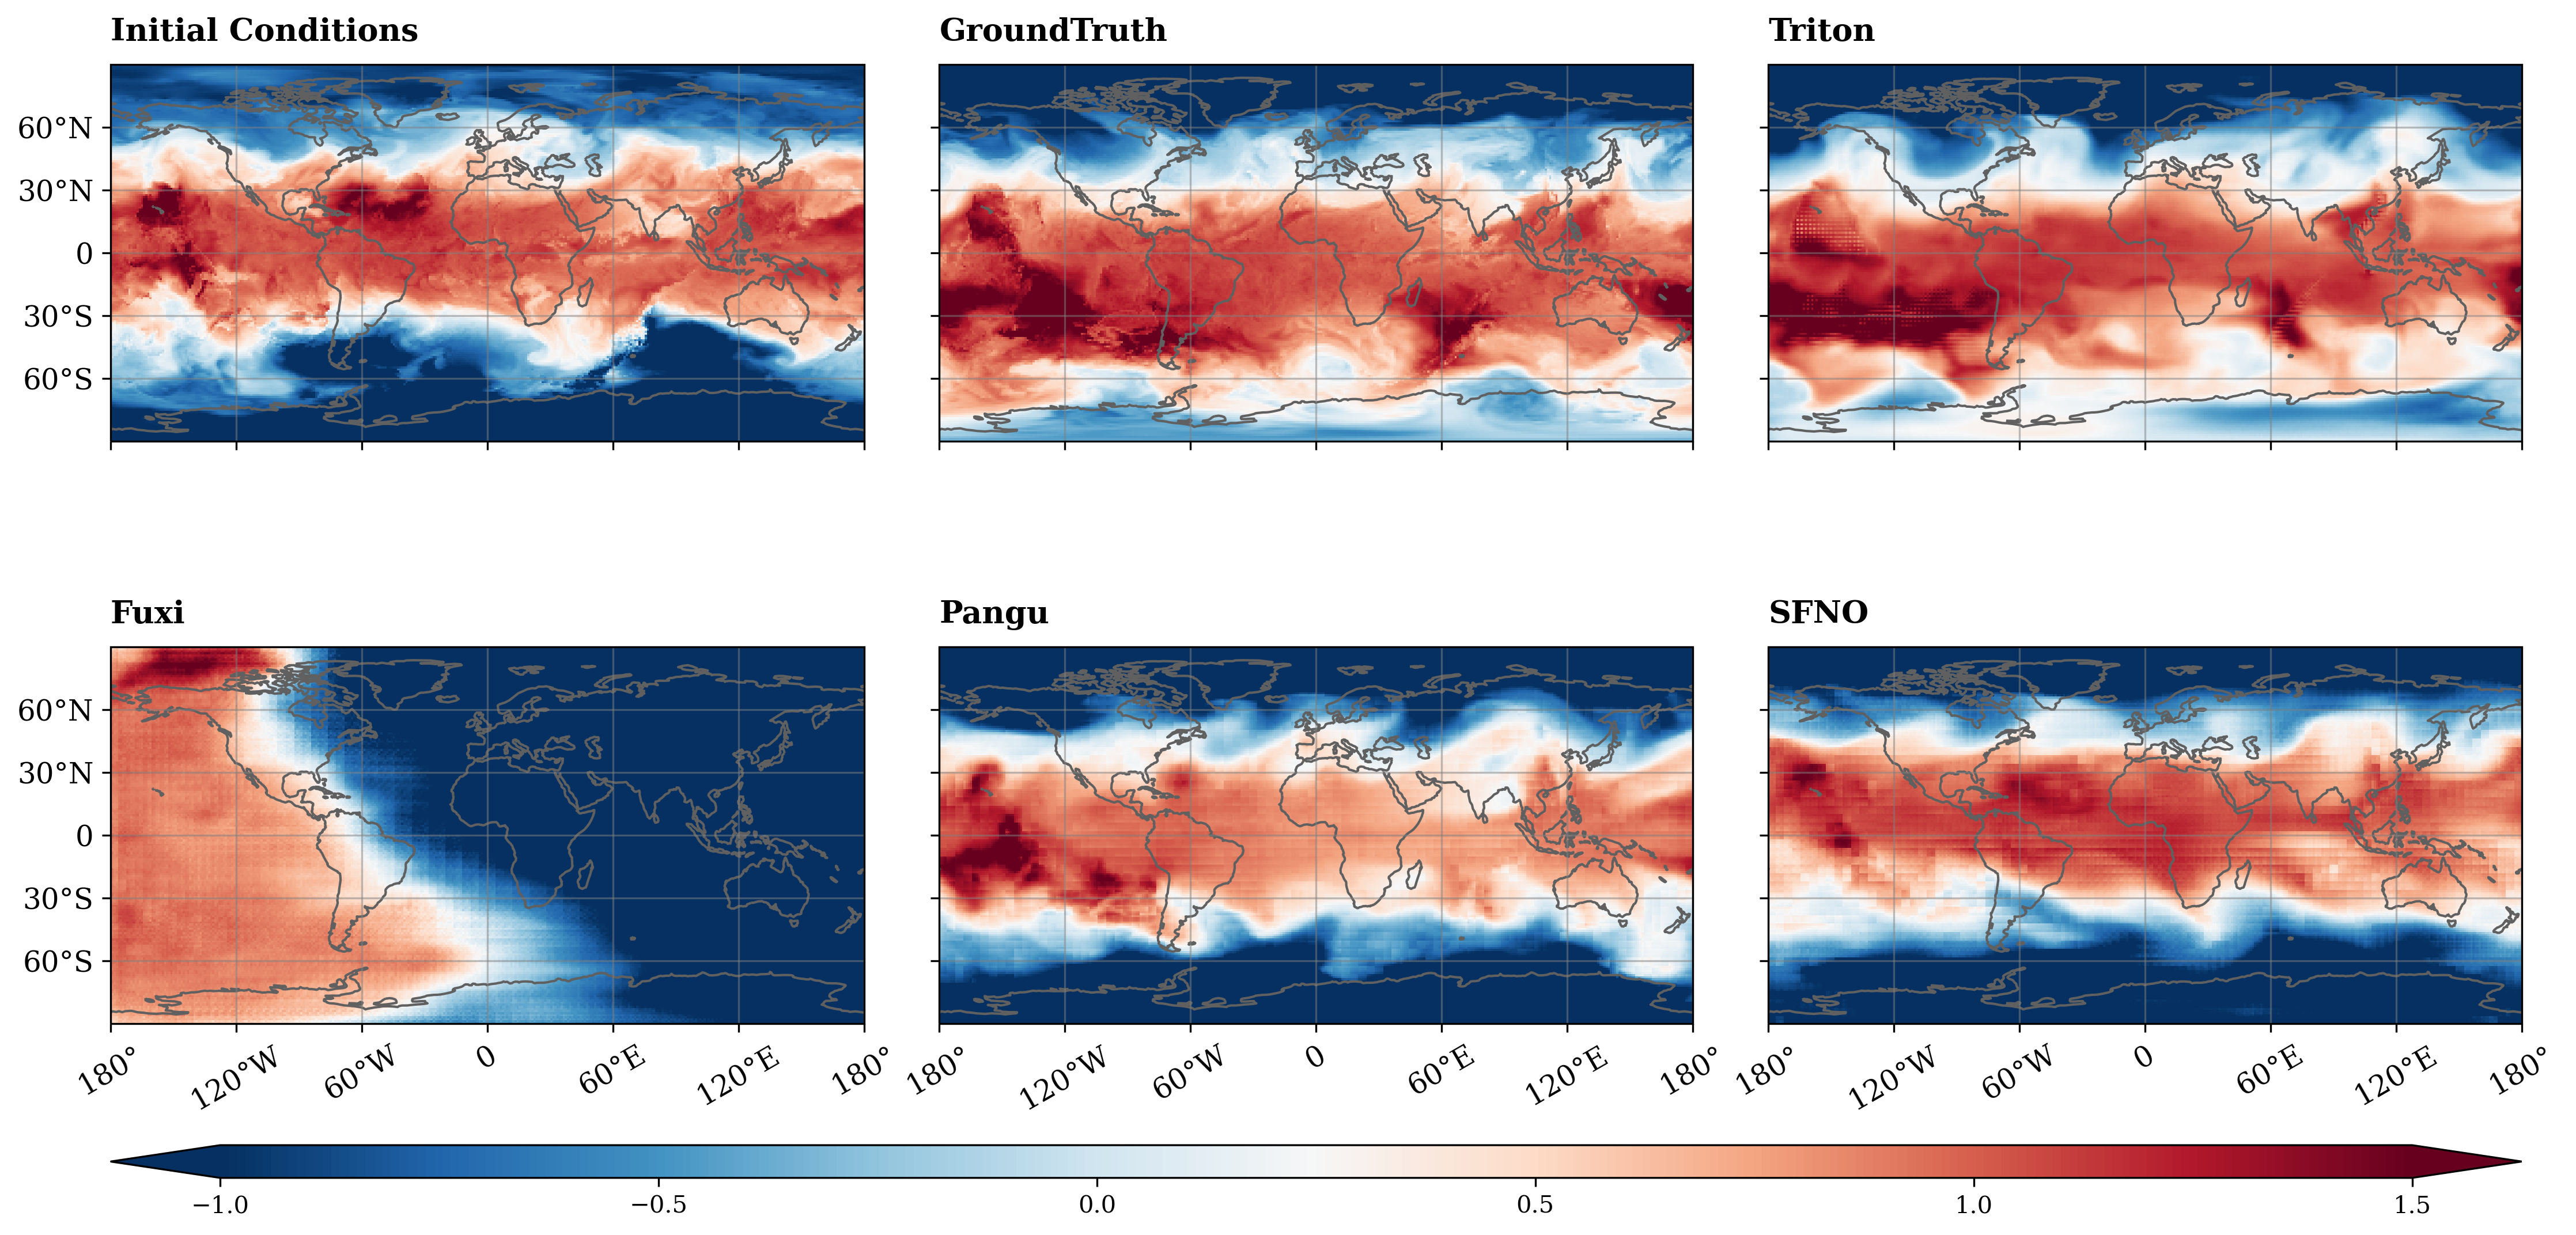

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "mathtext.fontset": "stix",
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8
})

DATA_CONFIG = {
    "models": {
        "Initial Conditions": "initial_input.npy",
        "GroundTruth": "groundtruth_210.npy",
        "Triton": "Triton_210_day.npy",
        "Fuxi": "Fuxi_210.npy",
        "Pangu": "Pangu_210.npy",
        "SFNO": "SFNO_210.npy"
    },
    "variable": {
        "index": 4 + 2 * 13 + 10,
        "cmap": "RdBu_r",
        "unit": "K",
        "bounds": (-1.0, 1.5)
    }
}

GEO_STYLE = {
    "coastline": {"linewidth": 1, "edgecolor": "#606060"},
    "gridlines": {"linewidth": 0.8, "color": "gray", "alpha": 0.5}
}

def create_map_axes(fig, gridspec_pos):
    ax = fig.add_subplot(gridspec_pos, projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, **GEO_STYLE["coastline"])
    ax.gridlines(**GEO_STYLE["gridlines"])
    return ax

fig = plt.figure(figsize=(18, 9), dpi=300)  
gs = GridSpec(nrows=3, ncols=3, 
             width_ratios=[1, 1, 1],
             height_ratios=[1, 1, 0.06],
             hspace=0.1, wspace=0.1)

data = {model: np.load(file) for model, file in DATA_CONFIG["models"].items()}
lon = np.linspace(-180, 180, 360)
lat = np.linspace(-90, 90, 180)

for row in range(2):
    for col in range(3):
        model_idx = row * 3 + col
        if model_idx >= len(DATA_CONFIG["models"]): 
            continue
            
        model_name = list(DATA_CONFIG["models"].keys())[model_idx]
        ax = create_map_axes(fig, gs[row, col])
        
        plot_data = data[model_name][DATA_CONFIG["variable"]["index"]]
        mesh = ax.pcolormesh(lon, lat, plot_data,
                           cmap=DATA_CONFIG["variable"]["cmap"],
                           vmin=DATA_CONFIG["variable"]["bounds"][0],
                           vmax=DATA_CONFIG["variable"]["bounds"][1],
                           transform=ccrs.PlateCarree())
        
        ax.set_xticks(np.arange(-180, 181, 60))
        ax.set_yticks(np.arange(-60, 61, 30))
        
        if row == 1:
            ax.set_xticklabels(['180°', '120°W', '60°W', '0', '60°E', '120°E', '180°'],
                              rotation=30, ha='center', fontsize=12)
        else:
            ax.set_xticklabels([])
            
        if col == 0:
            ax.set_yticklabels(['60°S', '30°S', '0', '30°N', '60°N'], fontsize=12)
        else:
            ax.set_yticklabels([])
            
        ax.set_title(model_name, fontsize=13, pad=10, loc='left', weight='bold')

# fig.suptitle("850hPa Temperature Anomaly Comparison", 
#             y=0.98, fontsize=16, weight='bold')

cax = fig.add_subplot(gs[2, :]) 
cbar = plt.colorbar(mesh, cax=cax, orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=10)
cbar.ax.xaxis.set_ticks_position('bottom')
cbar.ax.xaxis.set_label_position('bottom')

plt.savefig('T850_comparison.png', 
           bbox_inches='tight', 
           pad_inches=0.15,
           facecolor='white',
           dpi=600)

plt.show()